In [51]:
# M1: Load cleaned dataset
###Read citibike_weather_daily_clean.csv into a DataFrame
###Verify columns, dtypes, and that preprocessing carried over correctly

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/citibike_weather_daily_clean.csv')
df.head()

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month,day_of_week_encoded,days_since_launch
0,2013-07-01,16650,16.3,74.8,78.1,73.4,7.8,0.00,Monday,7,0,0
1,2013-07-02,22745,16.0,76.1,82.9,73.0,8.0,0.73,Tuesday,7,1,1
2,2013-07-03,21864,16.2,78.5,84.9,73.9,8.8,0.06,Wednesday,7,2,2
3,2013-07-04,22326,21.2,82.0,91.0,73.9,8.6,0.96,Thursday,7,3,3
4,2013-07-05,21842,18.0,84.4,93.0,75.9,9.0,0.00,Friday,7,4,4


In [52]:
df.dtypes

ride_date                  str
num_rides                int64
avg_duration_min       float64
temp_f                 float64
max_temp_f             float64
min_temp_f             float64
wind_speed_knots       float64
precip_in              float64
day_of_week                str
month                    int64
day_of_week_encoded      int64
days_since_launch        int64
dtype: object

In [53]:
df['ride_date'] = pd.to_datetime(df['ride_date'])

In [54]:
df.isna().sum()
#no missing values

ride_date              0
num_rides              0
avg_duration_min       0
temp_f                 0
max_temp_f             0
min_temp_f             0
wind_speed_knots       0
precip_in              0
day_of_week            0
month                  0
day_of_week_encoded    0
days_since_launch      0
dtype: int64

In [55]:
df.shape

#I loaded the cleaned dataset (citibike_weather_daily_clean.csv) and verified that all preprocessing steps were applied correctly. The dataset contains the expected columns, including the encoded day_of_week and trend feature, and all dtypes are appropriate for modeling. No missing values remain, and the dataset is ready for feature selection and model training.

(1610, 12)

In [56]:
#M2: Train/Test Split
###Use train_test_split to create X_train, X_test, y_train, y_test

X = df[['temp_f', 'max_temp_f', 'min_temp_f', 'wind_speed_knots',
        'precip_in', 'day_of_week_encoded', 'month', 'days_since_launch']]
y = df['num_rides']

#defining X and y >  all numeric, model‑ready columns
### Set y = num_rides
### Set X to numeric, model-ready features (weather, day_of_week_encoded, month, days_since_launch, etc.)



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#20% test size is the standard for time independent regression tasks


In [57]:
#Verifying the shape
X_train.shape , X_test.shape

###M2 Conclusion##

#I defined X as the set of numeric, model‑ready features 
#and y as the target variable (num_rides).

#Then, I performed a train/test split using an 80/20 ratio to ensure the model can be evaluated on 
#unseen data. The split is reproducible using random_state=42.



((1288, 8), (322, 8))

In [58]:
#M2.5 Fit the Core Model 
# Fit a LinearRegression on your core feature set: your chosen temperature feature, precipitation, wind, the day-of-week dummies, and your trend feature. Respect both Rules of the Road.
### Initialize model and Fit the model on training data 
from sklearn.linear_model import LinearRegression

model = LinearRegression() # Initialize model #
model.fit(X_train, y_train) # Fit model on training data #



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 422.58, 268.82, -168.4 ,...,-1183.53, 585.56, 16.77]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['temp_f','max_temp_f','min_temp_f',...,'day_of_week_encoded','month', 'days_since_launch']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.196e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [59]:
#M3: Evaluate the model
### Generate predictions on the training set and test set (Generate predictions on X_test)
### Compute R² for both training and test sets (Compute metrics -->  R^2 and RMSE)
### Compute test-set error in real units (rides)/ Compare predicted vs actual num_rides (testing model quality)

from sklearn.metrics import mean_absolute_error, mean_squared_error

## Predictions ##
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## R² scores ##
r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)

## Errors ##
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train, r2_test, mae, rmse


(0.7227826040493182,
 0.7260547117854241,
 7197.769917229072,
 np.float64(9067.006235956678))

In [60]:
#I used chatgpt to help print the outcomes in a more readable format to assist with my writeup

print(f"Train R²: {r2_train:.4f}")
print(f"Test R²: {r2_test:.4f}")
print(f"MAE: {mae:,.2f} rides")
print(f"RMSE: {rmse:,.2f} rides")

Train R²: 0.7228
Test R²: 0.7261
MAE: 7,197.77 rides
RMSE: 9,067.01 rides


## M3 Conclusion ##

The test R^2 tells us how well the model will predict future riderships rather than just the model memorizing patterns. We care more about the test R^2 than the training R^2 here, becuase the test score predicts how the model performs on dates it has never seen before. Opposed to the training model testing the outcomes of data it has already seen to learn the best-fit line.

The test R^2 = .7261 or 73% means the model we generated explains about 73% of the variation in daily reidership on new days. 

Computing MAE and RMSE on the test set helps to understand the error in units.

MAE - Mean Absolute Error measures the average size of the errors in our predictions. While, RMSE, Root Mean Squared Error, tells us how bad our errors are when we miss our target really badly.  

Our MAE is equal to 7,197.77 rides meaning our prediction is off about 7,200 rides on an average day.

Our RMSE is about 9,067.01 rides, which is larger than our MAE, as expected. RMSE penalizes large errors more heavily.The difference between our RMSE and MAE is roughly 1869 rides. (9067 - 7198 ~ 1869). The gap (1869 rides) between RMSE and MAE indicates that a few days had very large errors. Those days pretty much dominate the total error.   

The gap is likely/usually representative of days with unsual ridership patterns such as:
Major Holidays, Extreme Weather Events, Special NYC Events, and System Outages. 

This will not be captured by the model's features, resulting in those days dominating the total RMSE upward.Together, MAE and RMSE show that while the model performs reasonably well overall, it struggles on a handful of unusual days that our model does not have  features for those events, so it cannot predict/ capture those well.

In [61]:
#M4:Interpret the Coefficients
### Print the coeddicients next to their feature names 
### Identify the most interesting coefficients

import pandas as pd

coef_table = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_
})

coef_table

,feature,coefficient
0,temp_f,422.579383
1,max_temp_f,268.815559
2,min_temp_f,-168.395946
3,wind_speed_knots,-420.250765
4,precip_in,10.636698
5,day_of_week_encoded,-1183.525971
6,month,585.560316
7,days_since_launch,16.767329


#Identifying and discussing interesting coefficients 

## Temperature (temp_f = +422.58) ## 
Each additional degree Fahrenheit increases ridership by about 423 rides
This matches our EDA that warmer days would correlate with increased ridership. This means that a 10 degree warmer day could mean 4,200 more rides.

## Precipitation (precip_in = +10.64)  ##
Each additional inch of rain is associated with about 11 more rides, which is surprising because I expected rain to reduce ridership. It contradicts my EDA, which showed rain decreasing ridership.
This could have happened for multiple reasons: 
The precipitation variable might be mostly 0, with only a few non‑zero days.
The sentinel value 99.99 from earlier steps, may still be influencing the model.
The model may be picking up interactions from other features such as temperature or the month. 
Rainy ays might coinceide with system groth or weekend patterns inthe dataset. For example exploring perhaps if percipitation is high on one day, during the weekend, there may be higher ridership or system growth due to demand. 

## Trend (days_since_launch = 16.77) ##
Each additional day since launch adds about 17 rides, reflecting long‑term system growth.This matches our EDA that ridership increases over time. 

Overall, most coefficient signs match what our EDA led us to expect: temperature is positive and trend is positive. The precipitation coefficient is the main surprise, since it contradicts the negative relationship we observed in the scatter plots. This suggests the model may be picking up interactions or inconsistent patters in the precipitation variable.

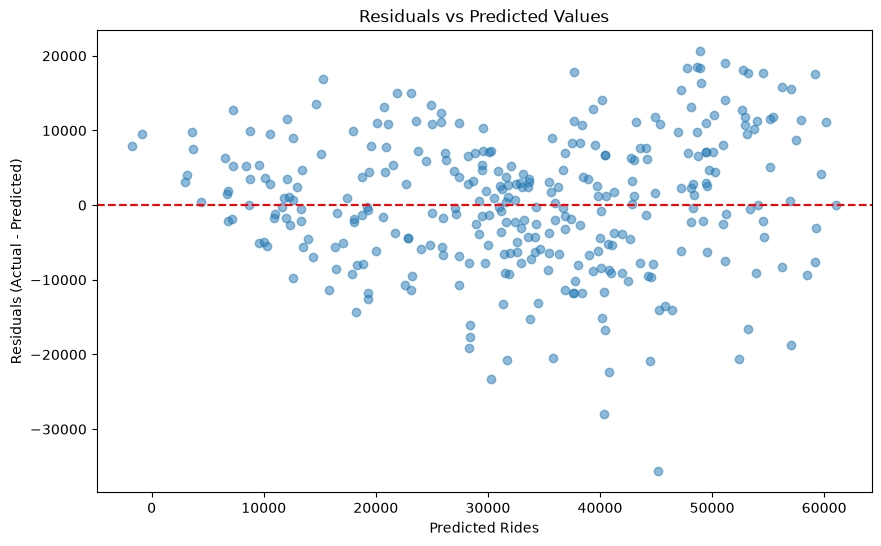

In [62]:
#M5 Diagnose with Residuals 
### Plot the residuals vs. predicted values
### Plot the residuals vs. ride_date

#Plot 1: Plot the residuals vs. predicted values
import matplotlib.pyplot as plt

residuals = y_test - y_test_pred

plt.figure(figsize=(10,6))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Rides")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.show()

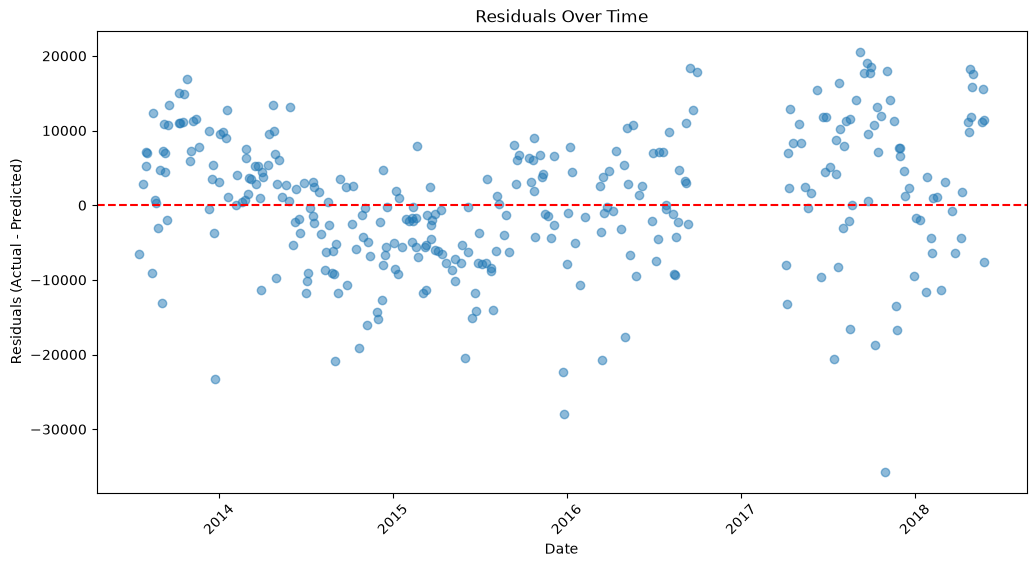

In [64]:
#Plot 2: Plot the residuals vs. ride_date

plt.figure(figsize=(12,6))
plt.scatter(df.loc[y_test.index,'ride_date'], residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Date")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Over Time")
plt.xticks(rotation=45)
plt.show()

#M5 Conclusion
We plotted the residuals both "actual" and "predicted" and against both predicted values and ride_date , to evaluate how well the model caputres the structure of daily ridership. 

## Residuals vs Predicted Values ##
The residuals appear mostly randomly scattered around zero, with no strong curve, clump, drift, or funnel shape. 

Thus, the model is not systematically over‑ or under‑predicting at different ridership levels. As outlined in previous compute, the large residual spikes likely correspond to: holidays, extreme weather, special NYC events, or outages. All situations the model cannot capture because those features are not included.

## Residuals Over Time ##

Residuals over time remain centered around zero without upward or downward drift. This shows that the model is not biased across the years and that adding the "days_since_launch" trend feature successfully corrected long‑term drift. 

The occasional large spikes represent unusual days with variant ridership patterns that the model cannot predict.

In [ ]:
#M6 Improve one thing 
#I tried to improve the model by transforming the precipitation feature, since its positive coefficient was surprising and may reflect irregularities.

#Im suspecting above all reasoning that sentinel values (like 99.99, even though we error correct in previous steps) or extreme outliers are intefering with the model 
#I plan to to cap the precipitation in inches at 5 inches and include this new variable in my feature set.

df['precip_in_clean'] = df['precip_in'].clip(upper=5)

X_improved = df[['temp_f', 'max_temp_f', 'min_temp_f', 'wind_speed_knots',
                 'precip_in_clean', 'day_of_week_encoded', 'month', 'days_since_launch']]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_improved, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

r2_before = model.score(X_test, y_test)
r2_after = model2.score(X_test2, y_test2)

r2_before, r2_after

(0.7260547117854241, 0.7332235483082095)


Based on the positive coefficient for precipitation in M4, which went against our EDA predictions, I made one targeted improvement to the model. NOAA GSOD data rarely exceeds ~5 inches of daily rainfall, and the dataset included a sentinel value (99.99) and other extreme values that could distort the linear regression. To reduce the impact of unrealistic precipitation values, I capped precipitation at 5 inches and created a "cleaned precipitation" feature (precip_in_clean).

I refit the model using this updated feature and compared the test R^2 before and after the change:

Original model test R^2: 0.72605

Improved model test R^2: 0.73322

This is a small improvement (+0.007), but it suggests that cleaning precipitation reduces noise and very slightly improves predictive accuracy. Even though the change did not dramatically shift performance, it provides useful insight into how sensitive the model is to extreme weather values. Although, the improvement was modest, it suggests that while extreme precipitation values can distort the model, precipitation itself plays a relatively small role in predicting daily ridership. Negative results are still results, and this experiment helps clarify the limited but measurable role precipitation plays in daily ridership.